In [102]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [103]:
df = pd.read_csv(r"C:\Users\efren\Desktop\DSCI\week10-visualization\assignment3\cycling_permanent_counts_daily.csv", parse_dates=['dt'])
df 


,_id,location_dir_id,location_name,direction,linear_name_full,side_street,dt,daily_volume
0,1,1,"Bloor St E, West of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-06-26,1046
1,2,1,"Bloor St E, West of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-06-28,1571
2,3,1,"Bloor St E, West of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-06-29,1306
3,4,1,"Bloor St E, West of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-07-01,1150
4,5,1,"Bloor St E, West of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-07-02,1007
...,...,...,...,...,...,...,...,...
40934,40935,39,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",Southbound,Murray Ross Pkwy,Shoreham Dr,2024-12-01,6
40935,40936,39,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",Southbound,Murray Ross Pkwy,Shoreham Dr,2024-12-02,4
40936,40937,39,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",Southbound,Murray Ross Pkwy,Shoreham Dr,2024-12-03,10
40937,40938,39,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",Southbound,Murray Ross Pkwy,Shoreham Dr,2024-12-04,10


In [104]:
df1 = df[ df["dt"].dt.year == 2024]
df1

,_id,location_dir_id,location_name,direction,linear_name_full,side_street,dt,daily_volume
12291,12292,3,"Bloor St W at Oakmount Rd, Display Counter",Eastbound,Bloor St W,Oakmount Rd,2024-01-01,63
12292,12293,3,"Bloor St W at Oakmount Rd, Display Counter",Eastbound,Bloor St W,Oakmount Rd,2024-01-02,131
12293,12294,3,"Bloor St W at Oakmount Rd, Display Counter",Eastbound,Bloor St W,Oakmount Rd,2024-01-03,191
12294,12295,3,"Bloor St W at Oakmount Rd, Display Counter",Eastbound,Bloor St W,Oakmount Rd,2024-01-04,164
12295,12296,3,"Bloor St W at Oakmount Rd, Display Counter",Eastbound,Bloor St W,Oakmount Rd,2024-01-05,161
...,...,...,...,...,...,...,...,...
40934,40935,39,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",Southbound,Murray Ross Pkwy,Shoreham Dr,2024-12-01,6
40935,40936,39,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",Southbound,Murray Ross Pkwy,Shoreham Dr,2024-12-02,4
40936,40937,39,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",Southbound,Murray Ross Pkwy,Shoreham Dr,2024-12-03,10
40937,40938,39,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",Southbound,Murray Ross Pkwy,Shoreham Dr,2024-12-04,10


In [105]:
grouped_data1 = df1 .groupby([ 'location_name',df1['dt'].dt.month])['daily_volume'].sum()
grouped_data1

location_name                                   dt
Bloor St W at Oakmount Rd, Display Counter      1      7860
                                                2     12746
                                                3     16606
                                                4     26513
                                                5     47204
                                                      ...  
YorkU - Murray Ross Pkwy, North of Shoreham Dr  8      1364
                                                9      1355
                                                10     1113
                                                11      778
                                                12       81
Name: daily_volume, Length: 161, dtype: int64

In [ ]:
#must be converted to a dataframe using reset_index
grouped_data2 = df1.groupby(['location_name', df1['dt'].dt.month])['daily_volume'].sum().reset_index()
grouped_data2.columns = ['location_name', 'month', 'total_daily_volume']
grouped_data2

,location_name,month,total_daily_volume
0,"Bloor St W at Oakmount Rd, Display Counter",1,7860
1,"Bloor St W at Oakmount Rd, Display Counter",2,12746
2,"Bloor St W at Oakmount Rd, Display Counter",3,16606
3,"Bloor St W at Oakmount Rd, Display Counter",4,26513
4,"Bloor St W at Oakmount Rd, Display Counter",5,47204
...,...,...,...
156,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",8,1364
157,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",9,1355
158,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",10,1113
159,"YorkU - Murray Ross Pkwy, North of Shoreham Dr",11,778


<Axes: xlabel='month', ylabel='total_daily_volume'>

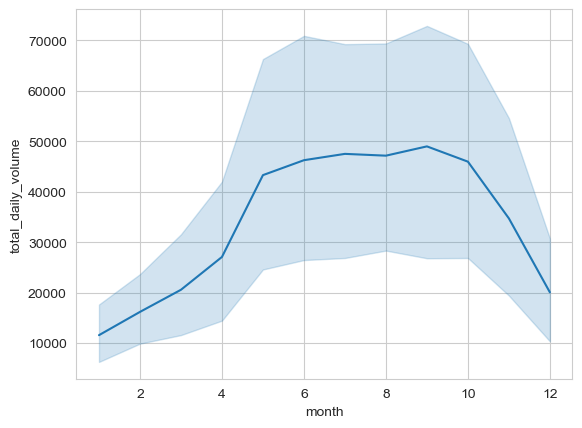

In [107]:
## this shows total ridership by month. all locations together

sns.set_style('whitegrid')

#simple line plot of tip amount vs total bill

sns.lineplot(data=grouped_data2, # choose our dataset
             x='month', # define our x variable
             y='total_daily_volume',
             ) # define our y variable

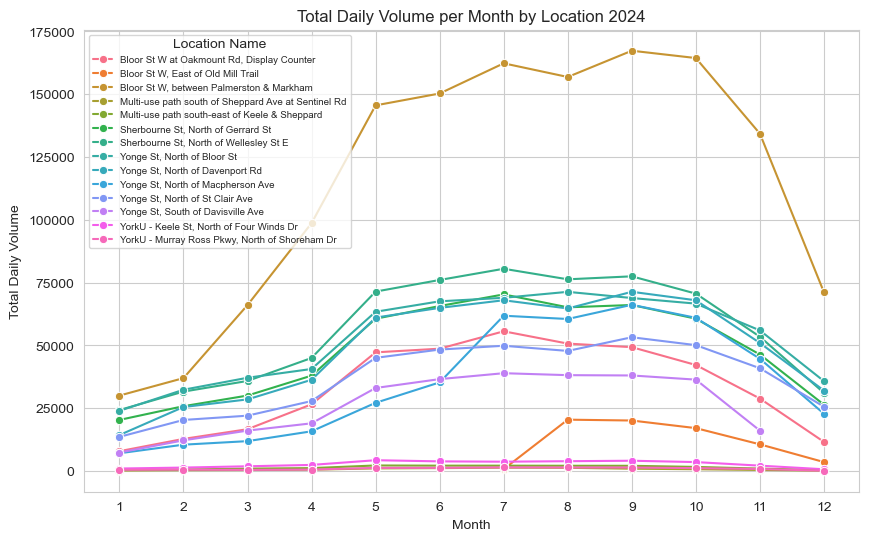

In [108]:
sns.set_style('whitegrid')

# Line plot with one line per location_name
plt.figure(figsize=(10, 6))  # Set figure size
sns.lineplot(data=grouped_data2, 
             x='month', 
             y='total_daily_volume', 
             hue='location_name',  # Different line per location, this creates the legend as well
             marker='o' # Add markers 
             )  

plt.xlabel("Month")  
plt.ylabel("Total Daily Volume")
plt.title("Total Daily Volume per Month by Location 2024")
plt.xticks(range(1, 13))  #month values are displayed correctly (1-12)
plt.legend(title="Location Name", prop={'size': 7}) 
plt.show()